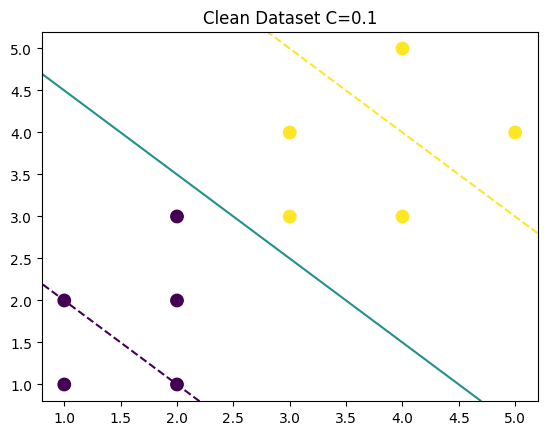

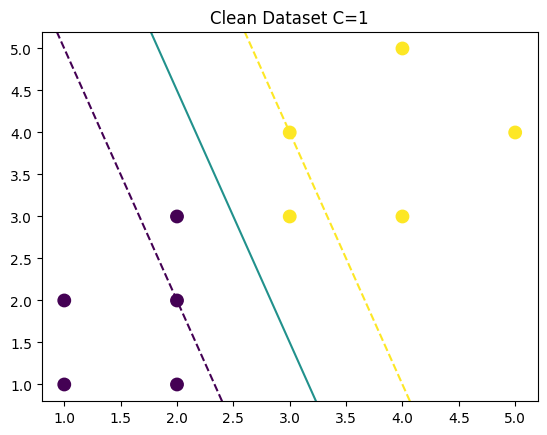

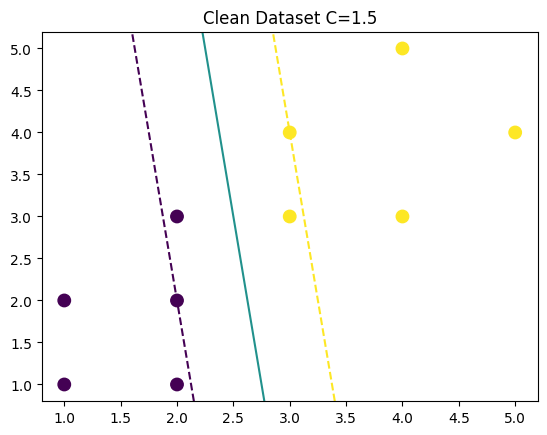

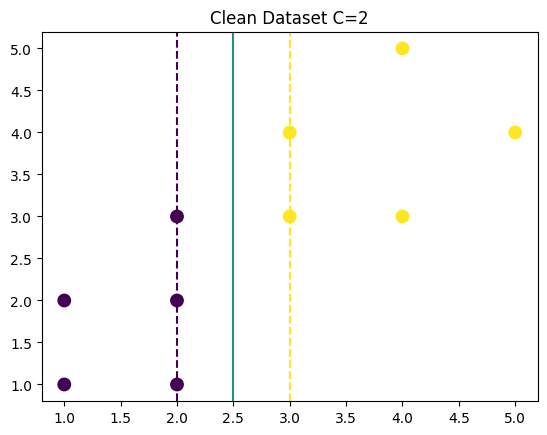

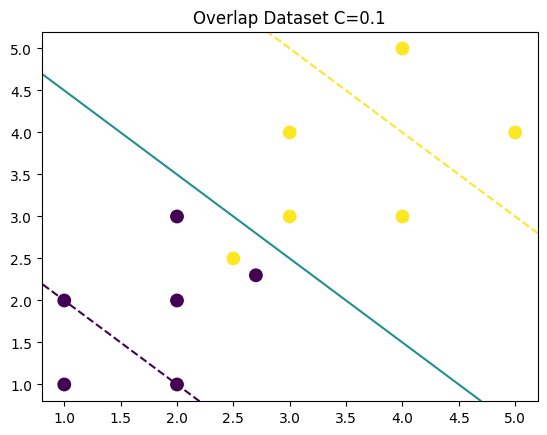

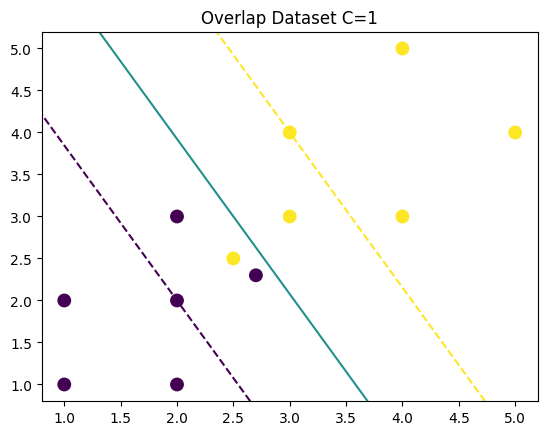

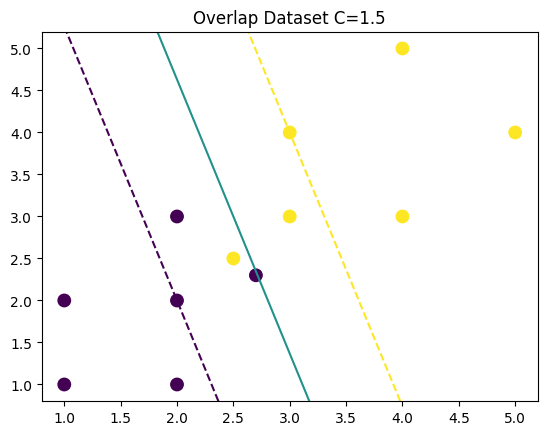

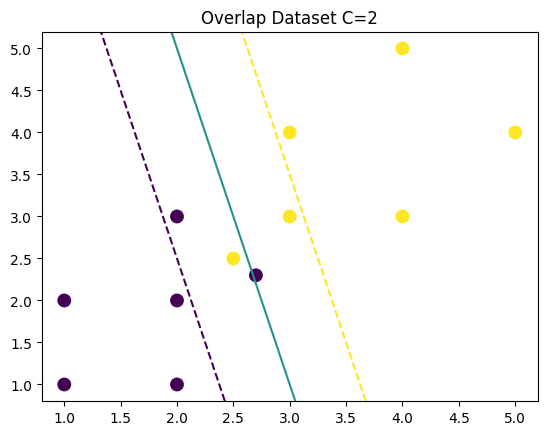

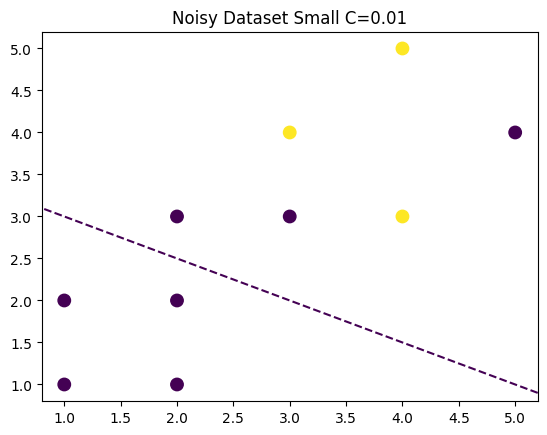

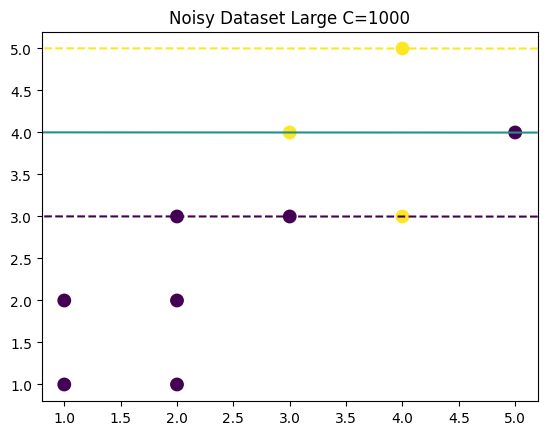

C = 0.1
Hinge Loss = 4.800000030517578
Support Vectors = 9



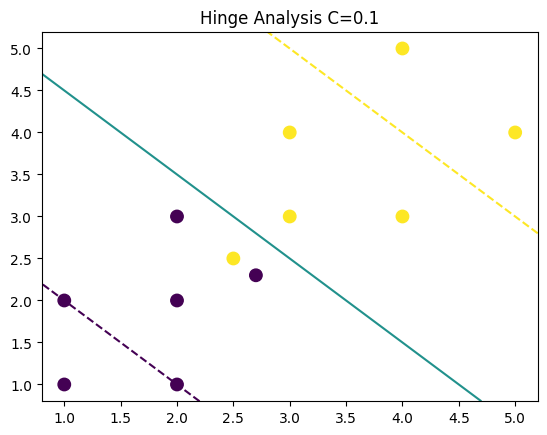

C = 1
Hinge Loss = 3.1280009460449216
Support Vectors = 6



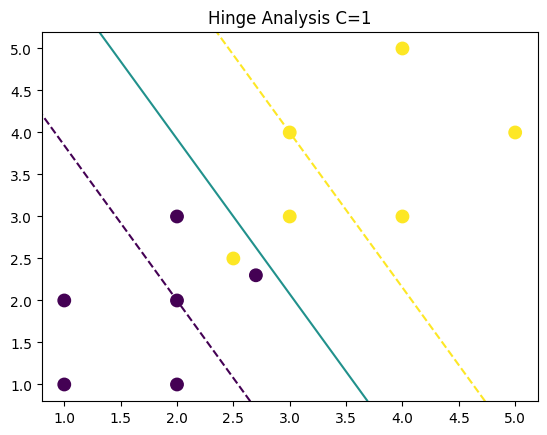

C = 1.5
Hinge Loss = 2.9320014190673827
Support Vectors = 6



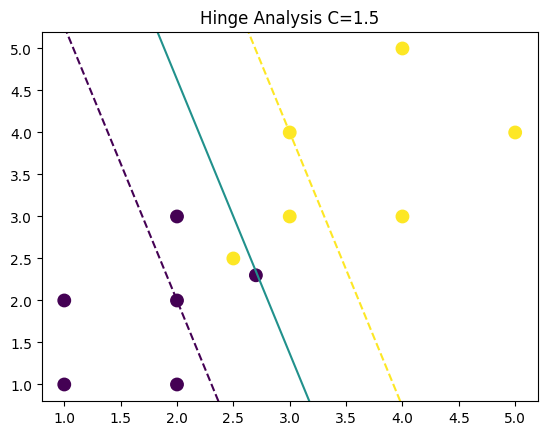

C = 2
Hinge Loss = 2.6400000000000006
Support Vectors = 4



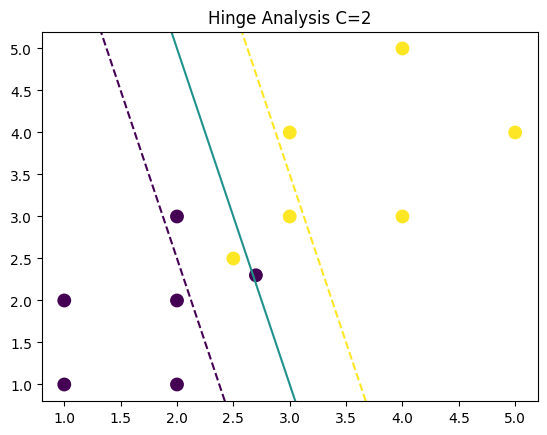

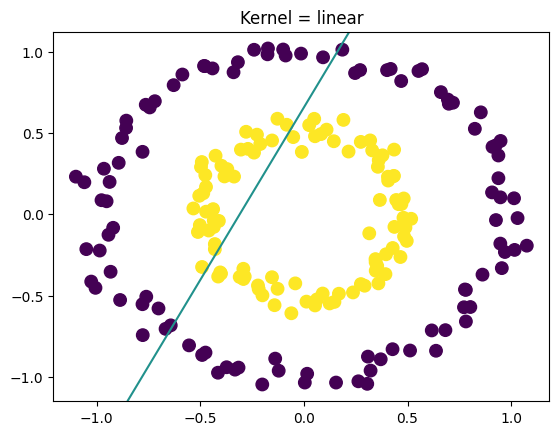

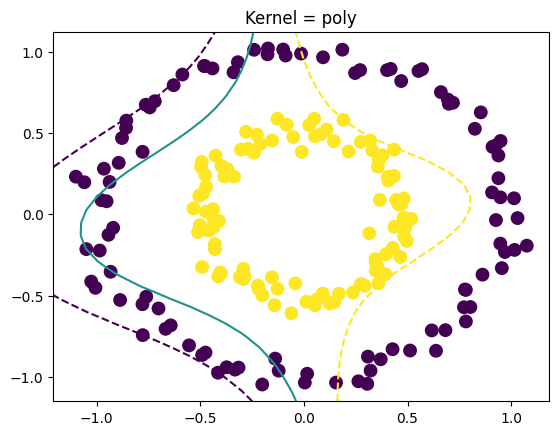

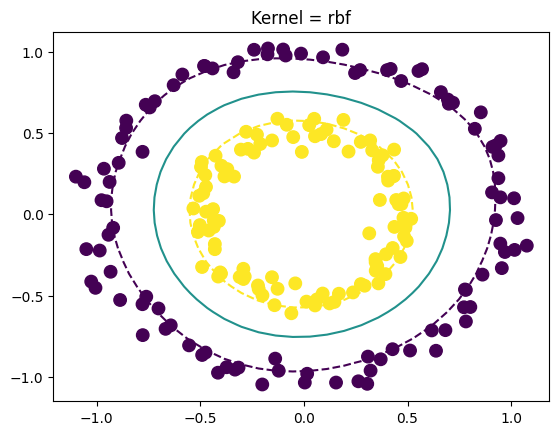

In [1]:
"""
Lab 4 Starter Code
Hard vs Soft Margin using C, Hinge Loss and Kernels

INSTRUCTIONS
------------
You will NOT implement SVM training.
You will use sklearn.

Your tasks are:

PART A:
Observe effect of C on clean and overlapping datasets.

PART B:
Observe noise sensitivity using large vs small C.

PART C:
Implement hinge loss and compute violations.

PART D:
Use kernels to separate nonlinear data.

DO NOT MODIFY:
- dataset functions
- evaluation helpers
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# ============================================================
# DATASETS (DETERMINISTIC)
# ============================================================

def dataset_clean():
    """
    D1: Clean Separable Dataset

    Description:
    - 10 points in 2D
    - First 5 points are positive class (+1)
    - Last 5 points are negative class (-1)
    - Fully linearly separable without overlap

    Instructions for students:
    - Use this dataset to observe SVM behaviour when data is clean
    - Suitable for Part A (effect of C)
    - Can visualize points using scatter plot with colors
    """
    X = np.array([
        [3,3],[4,3],[3,4],[5,4],[4,5],
        [1,1],[2,1],[1,2],[2,2],[2,3]
    ])
    y = np.array([1,1,1,1,1,-1,-1,-1,-1,-1])
    return X,y


def dataset_overlap():
    """
    D2: Overlapping Dataset

    Description:
    - 12 points in 2D
    - First 5 points are positive class (+1)
    - Two points in between classes to create overlap
    - Last 5 points are negative class (-1)
    - Not fully separable; some points lie in margin

    Instructions for students:
    - Use this dataset to see how SVM handles overlap
    - Observe how decision boundary changes with different C values
    - Useful for Part A (effect of C) and Part C (hinge loss analysis)
    """
    X = np.array([
        [3,3],[4,3],[3,4],[5,4],[4,5],
        [2.5,2.5],[2.7,2.3],
        [1,1],[2,1],[1,2],[2,2],[2,3]
    ])
    y = np.array([1,1,1,1,1,1,-1,-1,-1,-1,-1,-1])
    return X,y


def dataset_noisy():
    """
    D3: Noisy Dataset

    Description:
    - Based on dataset_clean
    - Two points intentionally misclassified (y values flipped)
    - Simulates noise in labels

    Instructions for students:
    - Use this dataset to see how SVM handles label noise
    - Compare model behaviour for very large vs small C
    - Useful for Part B (noise sensitivity)
    """
    X,y = dataset_clean()
    y[0] = -1  # introduce misclassification
    y[3] = -1
    return X,y

# ============================================================
# MODEL TRAINING
# ============================================================

def train_svm(X,y,C=1,kernel='linear'):
    """
    Train a SVM using sklearn.

    Instructions for students:
    - Use sklearn.svm.SVC with the specified kernel and C.
    - Fit the model to the dataset (X, y).
    - Return the trained model.
    """
    model = SVC(kernel=kernel,C=C)
    model.fit(X,y)
    return model

# ============================================================
# HINGE LOSS
# ============================================================

def hinge_loss(X,y,w,b):
    """
    Compute total hinge loss for a linear model.

    Instructions for students:
    - For each sample (x_i, y_i), compute:
        loss_i = max(0, 1 - y_i * (w^T x_i + b))
    - Sum over all samples to get total hinge loss.
    - Return the total loss.
    - Do NOT include any sklearn functions here; use only numpy.
    """
    if np.allclose(w,0):
        w = np.ones_like(w)*1e-6

    loss = 0

    for i in range(len(X)):
        val = 1 - y[i]*(np.dot(w,X[i]) + b)
        loss += max(0,val)

    return loss



# ============================================================
# EXTRACT MODEL PARAMETERS
# ============================================================

def get_w_b(model):
    """
    Extract weight vector and bias from a trained linear SVM.

    Instructions for students:
    - model.coef_ contains w
    - model.intercept_ contains b
    - Return w and b as numpy arrays/scalars
    """
    w = model.coef_[0]
    b = model.intercept_[0]

    if np.allclose(w,0):
        w = np.ones_like(w)*1e-6

    return w,b


# ============================================================
# PLOT DECISION BOUNDARY
# ============================================================

def plot_boundary(model,X,y,title):

    plt.figure()

    plt.scatter(X[:,0],X[:,1],c=y,s=80)

    ax = plt.gca()

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0],xlim[1],30)
    yy = np.linspace(ylim[0],ylim[1],30)

    YY,XX = np.meshgrid(yy,xx)

    xy = np.vstack([XX.ravel(),YY.ravel()]).T

    Z = model.decision_function(xy).reshape(XX.shape)

    ax.contour(XX,YY,Z,levels=[-1,0,1],linestyles=['--','-','--'])

    plt.title(title)

    plt.show()


# ============================================================
# PART A
# ============================================================

def part_A_effect_of_C():
    """
    Investigate effect of C on clean and overlapping datasets.

    Instructions for students:
    - Load dataset_clean() and dataset_overlap()
    - Train SVM with C = 0.01, 1, 1000 (use train_svm)
    - For each model:
        - Plot decision boundary and margins
        - Compare how boundaries change with C
    - Observe how large C leads to hard-margin-like behaviour
    """
    C_values = [0.1,1,1.5,2]

    X,y = dataset_clean()

    for C in C_values:

        model = train_svm(X,y,C)

        plot_boundary(model,X,y,f"Clean Dataset C={C}")


    X,y = dataset_overlap()

    for C in C_values:

        model = train_svm(X,y,C)

        plot_boundary(model,X,y,f"Overlap Dataset C={C}")




# ============================================================
# PART B
# ============================================================

def part_B_noise_sensitivity():
    """
    Analyze noise sensitivity using D3.

    Instructions for students:
    - Load dataset_noisy()
    - Train SVM with:
        - Very large C (e.g., 1000)
        - Small C (e.g., 0.01)
    - Plot both decision boundaries on the same figure
    - Observe which one is more robust to misclassified points
    """
    X,y = dataset_noisy()

    model_small = train_svm(X,y,C=0.01)

    model_large = train_svm(X,y,C=1000)

    plot_boundary(model_small,X,y,"Noisy Dataset Small C=0.01")

    plot_boundary(model_large,X,y,"Noisy Dataset Large C=1000")


# ============================================================
# PART C
# ============================================================

def part_C_hinge_analysis():
    """
    Compute hinge loss for dataset_overlap.

    Instructions for students:
    - Load dataset_overlap()
    - Train SVM with several C values (e.g., 0.01, 1, 10, 100)
    - Extract w, b for each model using get_w_b()
    - Compute total hinge loss using hinge_loss()
    - Compare magnitude of hinge loss for different C
    - Optional: count number of support vectors (model.support_vectors_)
    - Optional: plot decision boundaries for visualization
    """
    C_values = [0.1,1,1.5,2]

    X,y = dataset_overlap()

    for C in C_values:

        model = train_svm(X,y,C)

        w,b = get_w_b(model)

        loss = hinge_loss(X,y,w,b)

        print("C =",C)
        print("Hinge Loss =",loss)
        print("Support Vectors =",len(model.support_vectors_))
        print()

        plot_boundary(model,X,y,f"Hinge Analysis C={C}")

# ============================================================
# PART D
# ============================================================

def generate_circles():
    from sklearn.datasets import make_circles
    X,y = make_circles(n_samples=200,noise=0.05,factor=0.5,random_state=0)
    y[y==0] = -1
    return X,y

def part_D_kernels():
    """
    Use kernel SVMs to separate nonlinear data.

    Instructions for students:
    - Generate concentric circles dataset using generate_circles()
    - Train SVM using:
        - linear kernel
        - polynomial kernel
        - rbf kernel
    - Plot decision boundaries for each kernel
    - Compare performance and separability
    """
    X,y = generate_circles()

    kernels = ['linear','poly','rbf']

    for k in kernels:

        model = train_svm(X,y,C=1,kernel=k)

        plot_boundary(model,X,y,f"Kernel = {k}")

# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    part_A_effect_of_C()
    part_B_noise_sensitivity()
    part_C_hinge_analysis()
    part_D_kernels()